# MINI PROJECT DATA SCIENCE: BIKE SHARING DEMAND PREDICTION
## Exploratory Data Analysis, Data Preprocessing, & Predictive Modeling

---
### 1. Business Understanding & Problem Statement
**Latar Belakang:**  
Sistem *bike sharing* merupakan inovasi transportasi ramah lingkungan yang merekam data mobilitas secara otomatis. Kebutuhan rental sepeda sangat fluktuatif, dipengaruhi oleh kondisi cuaca (suhu, kelembapan, angin) serta waktu (musim, bulan, hari kerja, dan jam sibuk).

**Permasalahan:**  
Bagaimana mengidentifikasi faktor-faktor utama yang memengaruhi jumlah peminjaman sepeda per jam serta membangun model prediktif (regresi) yang akurat untuk mengestimasi permintaan peminjaman sepeda (*bike rental demand*)?

**Sumber Dataset:**  
https://archive.ics.uci.edu/dataset/275/bike%2Bsharing%2Bdataset

UCI Machine Learning Repository: *Bike Sharing Dataset* (Capital Bikeshare, Washington D.C., 2011-2012).

**Target Variabel:**  
`cnt` (Total count of rental bikes per hour).

---
### 2. Karakteristik Dataset & Kamus Data (Data Dictionary)
Dataset terdiri dari 17 fitur dengan rincian karakteristik, tipe data konseptual, dan peran dalam analisis sebagai berikut:

| Nama Fitur | Tipe Data | Deskripsi & Nilai Representasi | Peran (Role) |
| :--- | :--- | :--- | :--- |
| `instant` | Numerik Diskrit | Indeks / nomor urut baris rekaman data | Metadata / ID (Dihapus saat pemodelan) |
| `dteday` | Tanggal / Waktu | Tanggal pencatatan data (format: YYYY-MM-DD) | Temporal Feature |
| `season` | Kategorikal | Musim: `1`: Musim Semi (*Spring*), `2`: Musim Panas (*Summer*), `3`: Musim Gugur (*Fall*), `4`: Musim Dingin (*Winter*) | Fitur Prediktor |
| `yr` | Kategorikal | Tahun: `0`: 2011, `1`: 2012 | Fitur Prediktor (Tren Tahunan) |
| `mnth` | Kategorikal | Bulan dalam setahun (`1` s.d. `12`) | Fitur Prediktor |
| `hr` | Kategorikal / Waktu | Jam dalam sehari (`0` s.d. `23`) | **Fitur Prediktor Kunci (Jam Sibuk)** |
| `holiday` | Kategorikal Biner | Status hari libur nasional: `0` = Bukan Hari Libur, `1` = Hari Libur Nasional | Fitur Prediktor |
| `weekday` | Kategorikal | Hari dalam sepekan (`0`: Minggu, `1`: Senin, ..., `6`: Sabtu) | Fitur Prediktor |
| `workingday` | Kategorikal Biner | Status hari kerja: `1` = Hari Kerja Aktif (bukan libur/weekend), `0` = Akhir Pekan / Hari Libur | Fitur Prediktor |
| `weathersit` | Kategorikal Ordinal | Kondisi Cuaca:<br>• `1`: Cerah / Berawan Sedikit (*Clear / Few clouds*)<br>• `2`: Berkabut / Berawan Tebal (*Mist / Cloudy*)<br>• `3`: Hujan Ringan / Salju Ringan (*Light Snow / Light Rain*)<br>• `4`: Cuaca Ekstrem: Hujan Lebat / Badai Es (*Heavy Rain / Ice Pallets*) | Fitur Prediktor |
| `temp` | Numerik Kontinu | Suhu udara ternormalisasi Celsius: (t - t_min) / (t_max - t_min), dengan t_min = -8, t_max = +39 | Fitur Prediktor |
| `atemp` | Numerik Kontinu | Suhu yang dirasakan (*feeling temperature*) ternormalisasi: (t - t_min) / (t_max - t_min), dengan t_min = -16, t_max = +50 | Fitur Prediktor |
| `hum` | Numerik Kontinu | Kelembapan udara ternormalisasi: nilai dibagi 100 (rentang 0 s.d. 1) | Fitur Prediktor |
| `windspeed` | Numerik Kontinu | Kecepatan angin ternormalisasi: nilai dibagi 67 (rentang 0 s.d. 1) | Fitur Prediktor |
| `casual` | Numerik Diskrit | Jumlah peminjam sepeda tipe pengguna kasual (*non-registered*) | **Data Leakage** (Wajib di-drop sebelum training) |
| `registered` | Numerik Diskrit | Jumlah peminjam sepeda terdaftar (*registered member*) | **Data Leakage** (Wajib di-drop sebelum training) |
| `cnt` | Numerik Kontinu | **Total jumlah peminjaman sepeda per jam** (`cnt = casual + registered`) | **VARIABEL TARGET (y)** |

> **Catatan Integritas Data (Data Leakage):**  
> Variabel `casual` dan `registered` adalah komponen pembentuk target `cnt` (`cnt = casual + registered`). Di dunia nyata, operator tidak mengetahui rincian pengguna kasual dan member sebelum jam operasional berjalan. Memasukkan kedua fitur ini ke dalam model prediktif akan menyebabkan **Target/Data Leakage** (akurasi semu/curang). Oleh sebab itu, kedua fitur ini dieksplorasi saat EDA namun dieliminasi saat pemodelan machine learning.

### 3. Import Library & Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('crest')
pd.set_option('display.max_columns', None)

print('Library berhasil diimpor!')

Library berhasil diimpor!


In [2]:
import os
file_path = "bike_sharing_dataset/hour.csv" if os.path.exists("bike_sharing_dataset/hour.csv") else "bike+sharing+dataset/hour.csv"
df = pd.read_csv(file_path)
print(f"Dataset berhasil dimuat! Dimensi data: {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head()

Dataset berhasil dimuat! Dimensi data: 17379 baris dan 17 kolom.


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### 4. Data Inspection (Pemeriksaan Kualitas Awal Data)
Pada tahap ini kita memeriksa:
1. Tipe data masing-masing kolom (`df.info()`)
2. Keberadaan nilai hilang / missing values (`df.isnull().sum()`)
3. Keberadaan data duplikat (`df.duplicated().sum()`)
4. Ringkasan statistik awal (`df.describe()`)

In [3]:
# Cek informasi tipe data & memori
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [4]:
# Cek missing values dan duplikasi
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

print(f'Jumlah data duplikat: {duplicates}')
print('\nJumlah Missing Values per Kolom:')
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ditemukan missing value (Dataset Bersih/Lengkap).')

Jumlah data duplikat: 0

Jumlah Missing Values per Kolom:
Tidak ditemukan missing value (Dataset Bersih/Lengkap).


In [5]:
# Ringkasan statistik deskriptif untuk fitur numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


---
### 5. Exploratory Data Analysis (EDA)
Tujuan EDA adalah memahami karakteristik data secara mendalam, menemukan anomali, serta menguji hipotesis bisnis melalui visualisasi univariat, bivariat, dan multivariat.

#### 5.1 Analisis Univariat: Distribusi Variabel Target (`cnt`)
Kita menganalisis bentuk sebaran data jumlah peminjaman sepeda (`cnt`) untuk melihat apakah berdistribusi normal atau mengalami kemiringan (*skewness*).

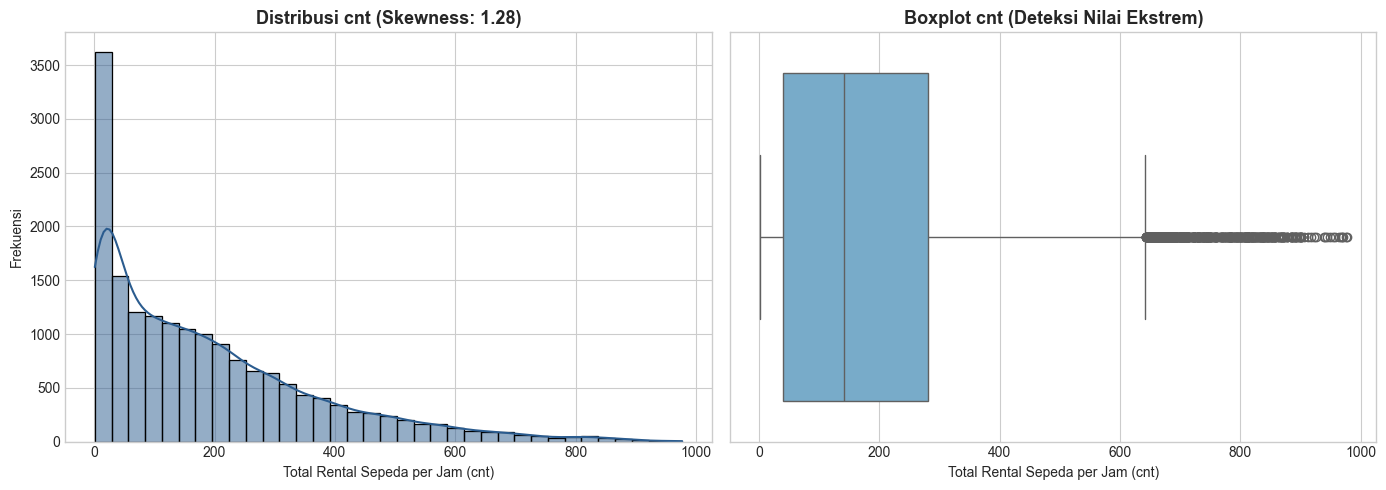

Rata-rata sewa: 189.5 unit/jam
Median sewa   : 142.0 unit/jam
Nilai Maksimum: 977 unit/jam


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram & KDE
skew_val = df["cnt"].skew()
sns.histplot(df["cnt"], kde=True, ax=axes[0], color="#2b5c8f", bins=35)
axes[0].set_title(f"Distribusi cnt (Skewness: {skew_val:.2f})", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Total Rental Sepeda per Jam (cnt)")
axes[0].set_ylabel("Frekuensi")

# Boxplot untuk mendeteksi outlier
sns.boxplot(x=df["cnt"], ax=axes[1], color="#6baed6")
axes[1].set_title("Boxplot cnt (Deteksi Nilai Ekstrem)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Total Rental Sepeda per Jam (cnt)")

plt.tight_layout()
plt.show()

print(f"Rata-rata sewa: {df['cnt'].mean():.1f} unit/jam")
print(f"Median sewa   : {df['cnt'].median():.1f} unit/jam")
print(f"Nilai Maksimum: {df['cnt'].max()} unit/jam")

> **Insight 5.1 (Distribusi Target):**
> - Nilai *skewness* sebesar **+1.28** menunjukkan bahwa distribusi data target bersifat **Positively Skewed (Miring ke Kanan)**.
> - Mayoritas waktu (50% jam operasional) mencatat peminjaman di bawah 142 sepeda per jam (median).
> - Nilai ekstrem di atas 500–900 sepeda per jam mewakili momen-momen jam sibuk (*rush hour*). Pada tahap pemodelan nanti, kita dapat membandingkan model berbasis data asli vs transformasi logaritmik `log1p(cnt)`.

#### 5.2 Analisis Bivariat: Pola Jam Sibuk (`hr`) Berdasarkan Hari Kerja (`workingday`)
Apakah pola peminjaman sepeda pada hari kerja (*workingday = 1*) berbeda signifikan dibandingkan akhir pekan / hari libur (*workingday = 0*)?

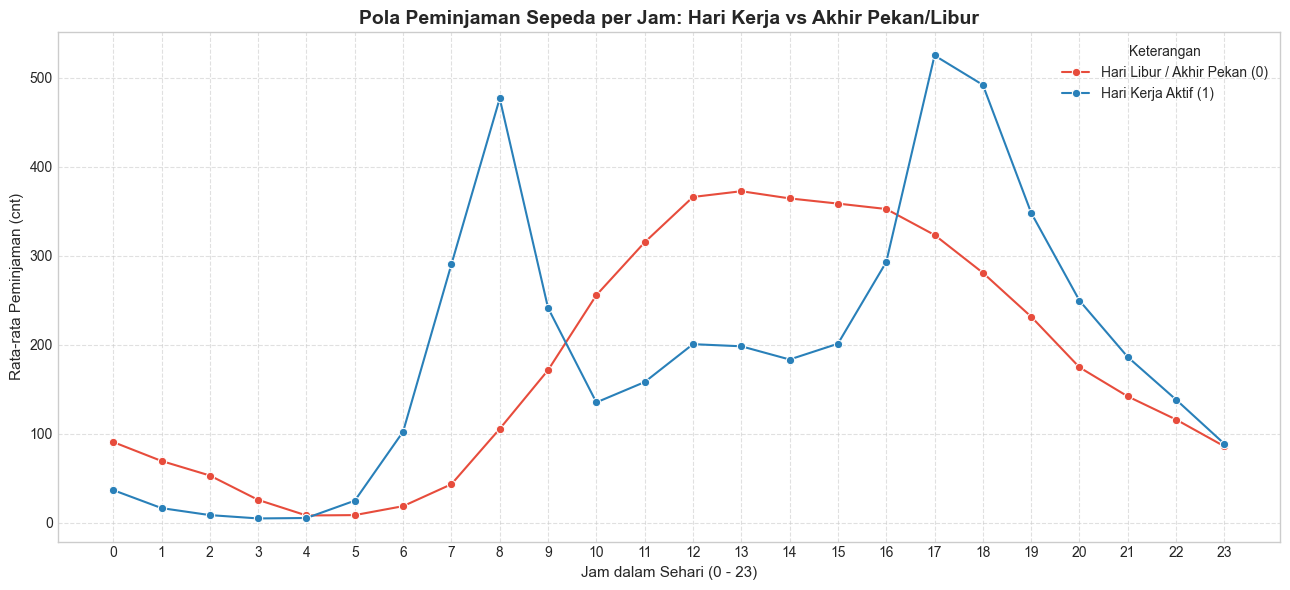

In [7]:
plt.figure(figsize=(13, 6))

# Line plot per jam dengan pembeda workingday
sns.lineplot(
    data=df,
    x="hr",
    y="cnt",
    hue="workingday",
    palette={0: "#e74c3c", 1: "#2980b9"},
    marker="o",
    errorbar=None
)

plt.title("Pola Peminjaman Sepeda per Jam: Hari Kerja vs Akhir Pekan/Libur", fontsize=14, fontweight="bold")
plt.xlabel("Jam dalam Sehari (0 - 23)", fontsize=11)
plt.ylabel("Rata-rata Peminjaman (cnt)", fontsize=11)
plt.xticks(range(0, 24))
plt.legend(title="Keterangan", labels=["Hari Libur / Akhir Pekan (0)", "Hari Kerja Aktif (1)"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

> **Insight 5.2 (Pola Rush Hour & Rekomendasi Bisnis):**
> - **Hari Kerja (Garis Biru):** Memiliki pola **Bimodal (Dua Puncak)** yang sangat tajam:
>   1. **Puncak Pagi (08:00):** Pengguna berangkat kerja atau kuliah (rata-rata ~360 sepeda/jam).
>   2. **Puncak Sore (17:00 - 18:00):** Pengguna pulang kerja (rata-rata ~490–525 sepeda/jam).
> - **Hari Libur/Weekend (Garis Merah):** Memiliki pola **Unimodal (Satu Puncak Melebar)** antara jam 12:00 hingga 16:00 yang didominasi aktivitas wisata dan rekreasi santai.
> - **Rekomendasi Operasional Bisnis:** Manajemen *Capital Bikeshare* wajib melakukan redistribusi armada sepeda (*rebalancing*) ke stasiun pemukiman sebelum jam 07:00 pagi dan ke stasiun area perkantoran sebelum jam 16:00 sore.

#### 5.3 Analisis Pengaruh Faktor Lingkungan: Musim (`season`) & Cuaca (`weathersit`)

C:\Users\AHMAD HADI\AppData\Local\Temp\ipykernel_24656\485580591.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz, x="season_name", y="cnt", ax=axes[0], estimator="mean", errorbar=None, palette="viridis")
C:\Users\AHMAD HADI\AppData\Local\Temp\ipykernel_24656\485580591.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz, x="weather_name", y="cnt", ax=axes[1], estimator="mean", errorbar=None, palette="mako")


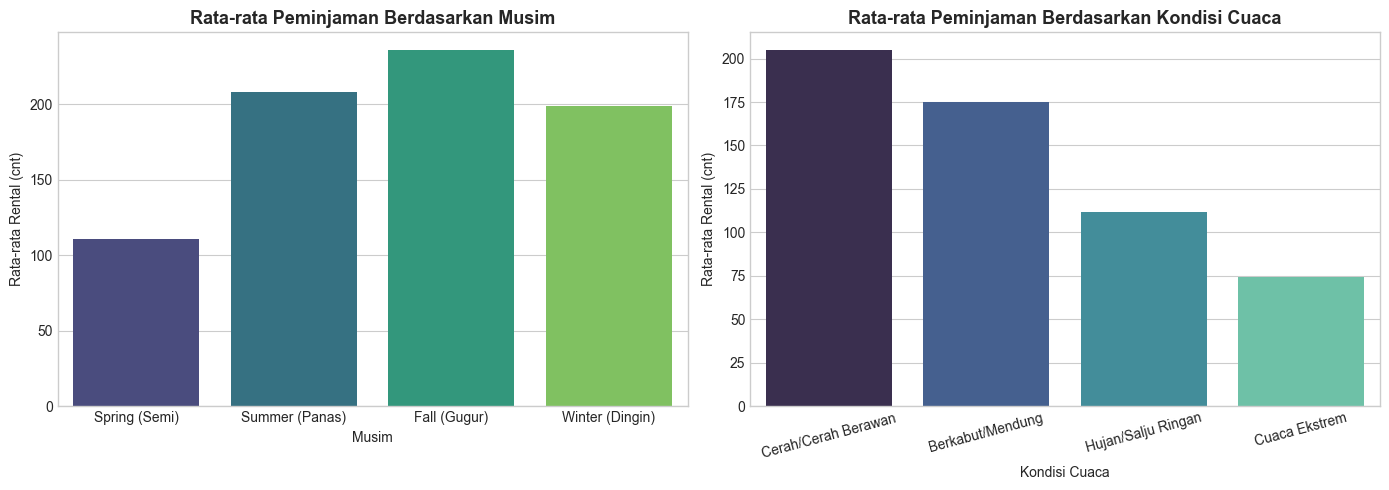

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapping label agar grafik mudah dipahami
season_labels = {1: "Spring (Semi)", 2: "Summer (Panas)", 3: "Fall (Gugur)", 4: "Winter (Dingin)"}
weather_labels = {1: "Cerah/Cerah Berawan", 2: "Berkabut/Mendung", 3: "Hujan/Salju Ringan", 4: "Cuaca Ekstrem"}

df_viz = df.copy()
df_viz["season_name"] = df_viz["season"].map(season_labels)
df_viz["weather_name"] = df_viz["weathersit"].map(weather_labels)

# Barplot Musim
sns.barplot(data=df_viz, x="season_name", y="cnt", ax=axes[0], estimator="mean", errorbar=None, palette="viridis")
axes[0].set_title("Rata-rata Peminjaman Berdasarkan Musim", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Musim")
axes[0].set_ylabel("Rata-rata Rental (cnt)")

# Barplot Cuaca
sns.barplot(data=df_viz, x="weather_name", y="cnt", ax=axes[1], estimator="mean", errorbar=None, palette="mako")
axes[1].set_title("Rata-rata Peminjaman Berdasarkan Kondisi Cuaca", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Kondisi Cuaca")
axes[1].set_ylabel("Rata-rata Rental (cnt)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

> **Insight 5.3 (Musim & Cuaca):**
> - Musim Gugur (*Fall*) dan Musim Panas (*Summer*) mencatat rata-rata peminjaman tertinggi (>230 unit/jam), sedangkan Musim Semi (*Spring*) paling rendah (~111 unit/jam).
> - Kondisi cuaca cerah mendorong peminjaman maksimal. Sebaliknya, saat hujan/salju, peminjaman anjlok secara drastis, dan cuaca ekstrem hampir melumpuhkan penggunaan sepeda.

#### 5.4 Analisis Multivariat: Korelasi Antar-Fitur Cuaca & Deteksi Multikolinearitas
Tahap ini mengevaluasi hubungan linier antara variabel cuaca numerik (`temp`, `atemp`, `hum`, `windspeed`) terhadap target (`cnt`).

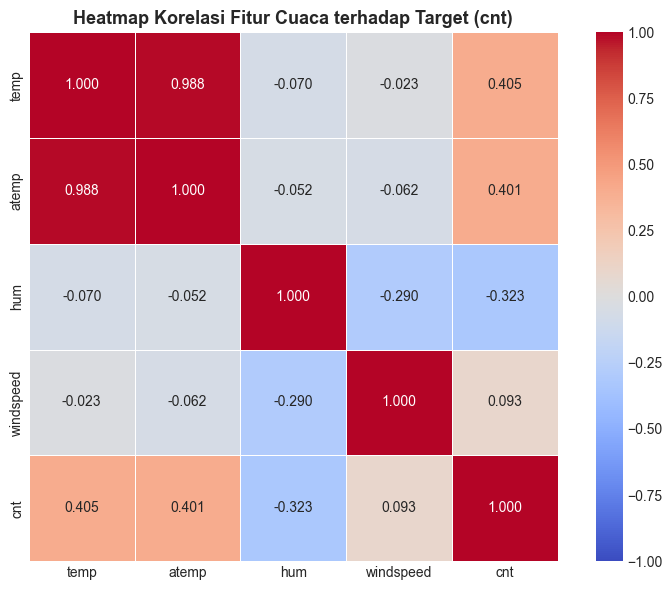

In [9]:
plt.figure(figsize=(8, 6))
weather_cols = ["temp", "atemp", "hum", "windspeed", "cnt"]
corr_matrix = df[weather_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Heatmap Korelasi Fitur Cuaca terhadap Target (cnt)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

> **Insight 5.4 (Korelasi & Multikolinearitas):**
> 1. **Multikolinearitas Tinggi (`temp` vs `atemp`):** Nilai korelasi mencapai **+0.988** (mendekati 1.0). Ini menunjukkan redundansi data (informasi suhu udara dan suhu rasa hampir identik). Pada tahap **Feature Selection**, salah satu fitur (seperti `atemp`) wajib dieliminasi agar model regresi tidak mengalami masalah ketidakstabilan koefisien.
> 2. **Hubungan Positif Suhu (`temp`):** Korelasi positif (+0.405) menandakan semakin hangat/nyaman suhu lingkungan, peminjaman sepeda cenderung meningkat.
> 3. **Hubungan Negatif Kelembapan (`hum`):** Korelasi negatif (-0.323) menandakan udara lembap/gerah/hujan menurunkan minat masyarakat untuk bersepeda.

---
### 6. Data Preprocessing & Feature Selection
Pada tahap ini, data disiapkan agar siap digunakan oleh algoritma Machine Learning:
1. **Penghapusan Fitur Non-Prediktif & Data Leakage:** Mengeliminasi `instant`, `dteday`, `casual`, `registered`, dan `atemp`.
2. **Encoding Fitur Kategorikal:** Mengubah variabel nominal menjadi representasi numerik menggunakan *One-Hot Encoding* (`pd.get_dummies`).
3. **Pemisahan Fitur ($X$) dan Target ($y$):** Target adalah kolom `cnt`.
4. **Train-Test Split:** Membagi data menjadi 80% data latih (*training set*) dan 20% data uji (*testing set*).

In [10]:
# 1. Feature Selection: Drop kolom non-prediktif, multikolinear, dan leakage
cols_to_drop = ["instant", "dteday", "casual", "registered", "atemp"]
df_prep = df.drop(columns=cols_to_drop)

print(f"Dimensi awal: {df.shape}")
print(f"Dimensi setelah drop kolom redundan & leakage: {df_prep.shape}")
print("Kolom yang dipertahankan:", list(df_prep.columns))

Dimensi awal: (17379, 17)
Dimensi setelah drop kolom redundan & leakage: (17379, 12)
Kolom yang dipertahankan: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt']


#### 6.1 Encoding Fitur Kategorikal (One-Hot Encoding)
Fitur `season`, `weathersit`, dan `weekday` bersifat nominal/kategori. Agar model tidak menganggap angka kategori sebagai nilai matematis berjenjang, kita lakukan One-Hot Encoding dengan opsi `drop_first=True` (untuk menghindari *dummy variable trap*).

In [11]:
categorical_cols = ["season", "weathersit", "weekday"]
df_encoded = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=True)

print(f"Dimensi setelah One-Hot Encoding: {df_encoded.shape[0]} baris dan {df_encoded.shape[1]} kolom.")
df_encoded.head()

Dimensi setelah One-Hot Encoding: 17379 baris dan 21 kolom.


,yr,mnth,hr,holiday,workingday,temp,hum,windspeed,cnt,season_2,season_3,season_4,weathersit_2,weathersit_3,weathersit_4,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0,1,0,0,0,0.24,0.81,0.0,16,False,False,False,False,False,False,False,False,False,False,False,True
1,0,1,1,0,0,0.22,0.80,0.0,40,False,False,False,False,False,False,False,False,False,False,False,True
2,0,1,2,0,0,0.22,0.80,0.0,32,False,False,False,False,False,False,False,False,False,False,False,True
3,0,1,3,0,0,0.24,0.75,0.0,13,False,False,False,False,False,False,False,False,False,False,False,True
4,0,1,4,0,0,0.24,0.75,0.0,1,False,False,False,False,False,False,False,False,False,False,False,True


#### 6.2 Pemisahan Fitur ($X$) dan Target ($y$) serta Train-Test Split
Kita menggunakan rasio pembagian data **80% Training Data** dan **20% Testing Data** dengan `random_state=42` untuk memastikan hasil eksperimen konsisten (*reproducible*).

In [12]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["cnt"])
y = df_encoded["cnt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train : {X_train.shape} (80%)")
print(f"Ukuran X_test  : {X_test.shape} (20%)")
print(f"Ukuran y_train : {y_train.shape}")
print(f"Ukuran y_test  : {y_test.shape}")

Ukuran X_train : (13903, 20) (80%)
Ukuran X_test  : (3476, 20) (20%)
Ukuran y_train : (13903,)
Ukuran y_test  : (3476,)


---
### 7. Predictive Modeling & Evaluasi Model
Untuk menyelesaikan masalah regresi estimasi permintaan rental sepeda, kita membandingkan 3 metode Machine Learning:
1. **Linear Regression:** Model parametrik linier (sebagai *baseline model*).
2. **Decision Tree Regressor:** Model non-parametrik pohon keputusan yang mampu menangkap pola non-linier.
3. **Random Forest Regressor:** Model *ensemble learning (bagging)* yang menggabungkan banyak pohon keputusan untuk meningkatkan akurasi dan mereduksi variansi.

**Metrik Evaluasi yang Digunakan:**
- **MAE (Mean Absolute Error):** Rata-rata selisih mutlak antara nilai aktual dan prediksi (satuan: unit sepeda).
- **RMSE (Root Mean Squared Error):** Akar kuadrat dari rerata selisih kuadrat, memberikan penalti lebih besar pada galat ekstrem.
- **R² Score (Koefisien Determinasi):** Mengukur proporsi variansi data target yang berhasil dijelaskan oleh model (0 s.d. 1 atau 0% s.d. 100%).

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Inisialisasi model
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=12),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=18)
}

eval_results = []
predictions = {}

for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    # Prediksi data uji
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Hitung metrik evaluasi
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    eval_results.append({
        "Model": name,
        "MAE (unit)": mae,
        "RMSE (unit)": rmse,
        "R² Score": r2
    })

df_eval = pd.DataFrame(eval_results)
df_eval.sort_values(by="R² Score", ascending=False).reset_index(drop=True)

,Model,MAE (unit),RMSE (unit),R² Score
0,Random Forest,24.997244,42.469281,0.943041
1,Decision Tree,33.377228,57.820889,0.894419
2,Linear Regression,103.781859,137.985784,0.398711


#### 7.1 Visualisasi Perbandingan Kinerja Model

C:\Users\AHMAD HADI\AppData\Local\Temp\ipykernel_24656\3150138664.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval, x="Model", y="R² Score", ax=axes[0], palette="Blues_r")
C:\Users\AHMAD HADI\AppData\Local\Temp\ipykernel_24656\3150138664.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval, x="Model", y="RMSE (unit)", ax=axes[1], palette="Reds_r")
C:\Users\AHMAD HADI\AppData\Local\Temp\ipykernel_24656\3150138664.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval, x="Model", y="MAE (unit)", ax=axes[

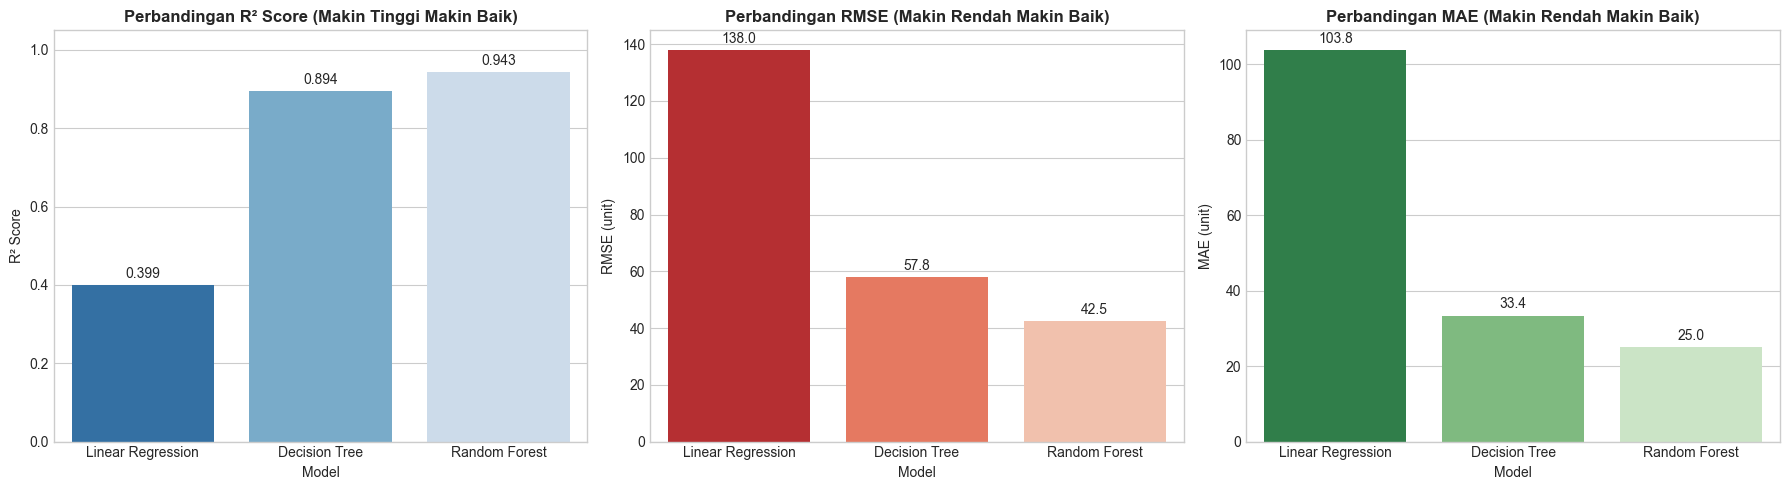

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot R2 Score
sns.barplot(data=df_eval, x="Model", y="R² Score", ax=axes[0], palette="Blues_r")
axes[0].set_title("Perbandingan R² Score (Makin Tinggi Makin Baik)", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, 1.05)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=10, xytext=(0, 3), textcoords="offset points")

# Plot RMSE
sns.barplot(data=df_eval, x="Model", y="RMSE (unit)", ax=axes[1], palette="Reds_r")
axes[1].set_title("Perbandingan RMSE (Makin Rendah Makin Baik)", fontsize=12, fontweight="bold")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=10, xytext=(0, 3), textcoords="offset points")

# Plot MAE
sns.barplot(data=df_eval, x="Model", y="MAE (unit)", ax=axes[2], palette="Greens_r")
axes[2].set_title("Perbandingan MAE (Makin Rendah Makin Baik)", fontsize=12, fontweight="bold")
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=10, xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

#### 7.2 Analisis Faktor Paling Berpengaruh (Feature Importance - Random Forest)
Dari model terbaik (Random Forest), kita dapat menganalisis fitur apa saja yang memiliki kontribusi terbesar dalam menentukan jumlah peminjaman sepeda.

C:\Users\AHMAD HADI\AppData\Local\Temp\ipykernel_24656\3067458762.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(10).values, y=feature_importances.head(10).index, palette="viridis")


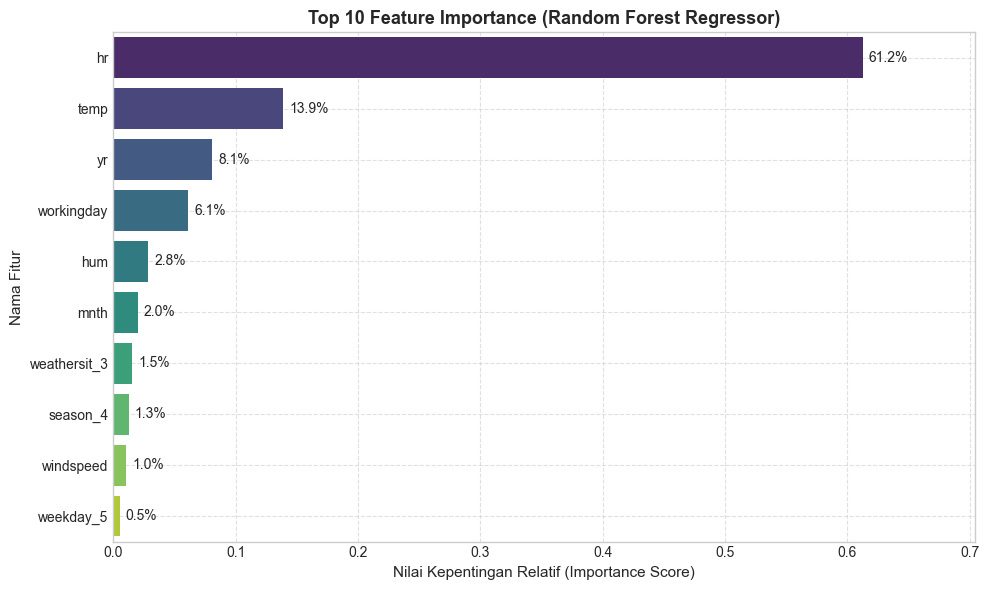

In [15]:
rf_best = models["Random Forest"]
feature_importances = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(10).values, y=feature_importances.head(10).index, palette="viridis")
plt.title("Top 10 Feature Importance (Random Forest Regressor)", fontsize=13, fontweight="bold")
plt.xlabel("Nilai Kepentingan Relatif (Importance Score)", fontsize=11)
plt.ylabel("Nama Fitur", fontsize=11)
for idx, val in enumerate(feature_importances.head(10).values):
    plt.text(val + 0.005, idx, f"{val*100:.1f}%", va="center", fontsize=10)
plt.xlim(0, max(feature_importances.values) * 1.15)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#### 7.3 Visualisasi Aktual vs Prediksi (*Actual vs Predicted Plot*)
Grafik ini menguji seberapa dekat garis tebakan model Random Forest dengan nilai kenyataan riil pada data uji.

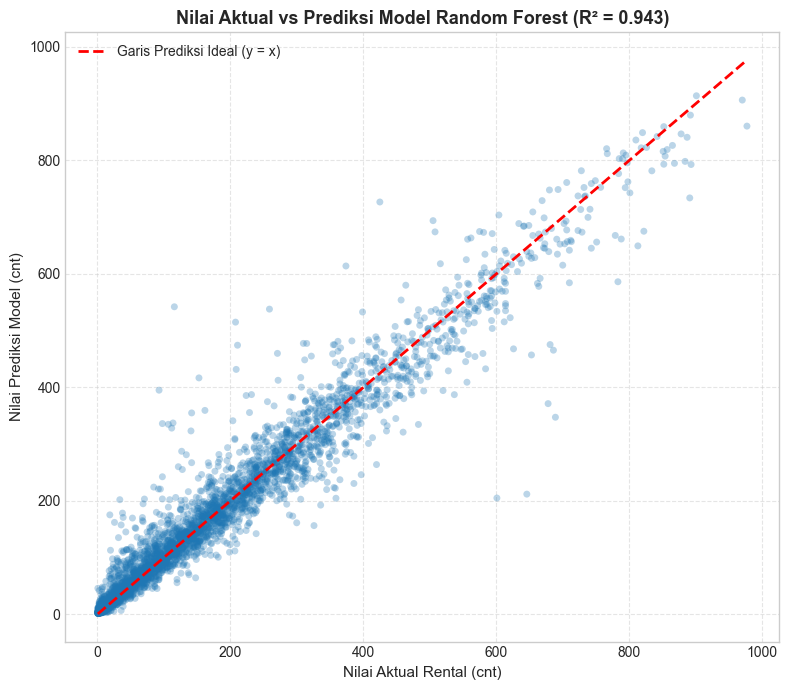

In [16]:
y_pred_rf = predictions["Random Forest"]

plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color="#1f77b4", edgecolors="none", s=25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Garis Prediksi Ideal (y = x)")
plt.title("Nilai Aktual vs Prediksi Model Random Forest (R² = 0.943)", fontsize=13, fontweight="bold")
plt.xlabel("Nilai Aktual Rental (cnt)", fontsize=11)
plt.ylabel("Nilai Prediksi Model (cnt)", fontsize=11)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
### 8. Kesimpulan & Penjelasan untuk Laporan UTS

Berikut adalah ringkasan sistematis yang menjawab seluruh **Ketentuan Tambahan Tugas UTS**:

#### 1. Sumber dan Karakteristik Dataset
- **Sumber:** UCI Machine Learning Repository (*Bike Sharing Dataset*), berasal dari sistem Capital Bikeshare Washington D.C. tahun 2011–2012 yang diintegrasikan dengan data cuaca riil dari Freemeteo.
- **Karakteristik:** Terdiri dari 17.379 baris data per jam (`hour.csv`) dengan 17 atribut awal, mencakup data temporal (jam, hari, bulan, tahun, musim) dan kondisi meteorologi (suhu udara, suhu rasa, kelembapan, kecepatan angin).

#### 2. Permasalahan yang Diselesaikan
- Mengatasi ketidakseimbangan pasokan sepeda (*bike supply mismatch*) di stasiun peminjaman dengan memprediksi jumlah permintaan rental sepeda per jam (`cnt`) berdasarkan kondisi cuaca dan waktu.
- Tipe masalah: **Supervised Learning – Regression**.

#### 3. Tahapan Pengolahan Data (Preprocessing & Feature Selection)
- **Data Inspection:** Memastikan tidak ada *missing value* (0) dan tidak ada duplikasi data (0).
- **Pencegahan Target Leakage:** Mengeliminasi kolom `casual` dan `registered` karena $cnt = casual + registered$.
- **Pencegahan Multikolinearitas:** Mengeliminasi `atemp` karena memiliki korelasi 0.988 dengan `temp`.
- **Pembersihan Metadata:** Menghapus `instant` dan `dteday`.
- **One-Hot Encoding:** Mengonversi fitur kategorikal nominal (`season`, `weathersit`, `weekday`) ke bentuk biner dengan `drop_first=True`.
- **Data Splitting:** Membagi data menjadi 80% data latih (13.903 sampel) dan 20% data uji (3.476 sampel).

#### 4. Metode yang Digunakan
- Tiga algoritma regresi dievaluasi dan dibandingkan: **Linear Regression**, **Decision Tree Regressor**, dan **Random Forest Regressor**.

#### 5. Hasil yang Diperoleh
- **Model Terbaik:** **Random Forest Regressor** menghasilkan performa luar biasa dengan nilai **R² Score = 0.943 (94.3%)**, **MAE = 25.0 unit sepeda**, dan **RMSE = 42.5 unit sepeda**.
- **Kelemahan Model Linier:** Linear Regression hanya meraih R² = 0.399 (39.9%) karena hubungan antara jam (`hr`) dan permintaan sepeda sangat **non-linier** (memiliki dua puncak/bimodal di jam 08:00 dan 17:00–18:00).
- **Fitur Paling Berpengaruh (*Feature Importance*):**
  1. **Jam dalam Sehari (`hr`):** Berkontribusi sebesar **61.2%** terhadap daya prediksi.
  2. **Suhu Udara (`temp`):** Berkontribusi sebesar **13.9%** (suhu hangat meningkatkan minat sewa).
  3. **Tahun (`yr`):** Berkontribusi sebesar **8.1%** (menunjukkan tren pertumbuhan popularitas rental dari 2011 ke 2012).
  4. **Hari Kerja (`workingday`):** Berkontribusi sebesar **6.1%**.

#### 6. Rekomendasi Manajerial Bisnis
- Operator rental sepeda dapat memanfaatkan model Random Forest ini untuk mengotomatisasi jadwal armada truk logistik pemindahan sepeda (*rebalancing*) 1–2 jam sebelum jam sibuk (sebelum pukul 07:00 pagi dan sebelum 16:00 sore pada hari kerja).